In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout

In [11]:
data = pd.read_csv("../data/Breast_Cancer.csv")

In [12]:
data.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
7,40,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,9,1,14,Dead
8,40,White,Divorced,T4,N3,IIIC,Poorly differentiated,3,Regional,103,Positive,Positive,20,18,70,Alive
9,69,White,Married,T4,N3,IIIC,Well differentiated,1,Distant,32,Positive,Positive,21,12,92,Alive


In [13]:
data.tail(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4014,40,White,Married,T3,N1,IIIA,Moderately differentiated,2,Regional,68,Positive,Positive,22,2,86,Alive
4015,65,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,40,Positive,Positive,4,4,68,Alive
4016,54,White,Married,T2,N1,IIB,Well differentiated,1,Regional,50,Positive,Positive,29,2,52,Alive
4017,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,28,Negative,Negative,2,1,19,Dead
4018,64,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,10,Positive,Positive,11,1,70,Alive
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [15]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [16]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')

In [17]:
data.shape

(4024, 16)

In [18]:
data.dtypes

Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                      str
dtype: object

In [19]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [20]:
data.duplicated().sum()

np.int64(1)

In [21]:
data.nunique()

Age                        40
Race                        3
Marital Status              5
T Stage                     4
N Stage                     3
6th Stage                   5
differentiate               4
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

<Axes: >

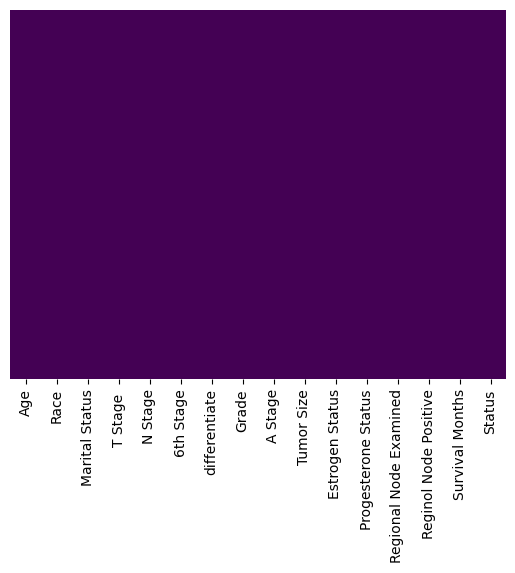

In [22]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [47]:
categorical_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage',
    '6th Stage', 'differentiate', 'Grade', 'A Stage',
    'Estrogen Status', 'Progesterone Status', 'Status'
]

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [24]:
data.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0
5,51,2,3,0,0,0,0,2,1,20,1,1,18,2,89,0
6,51,2,1,0,0,0,3,1,1,8,1,1,11,1,54,0
7,40,2,1,1,0,1,0,2,1,30,1,1,9,1,14,1
8,40,2,0,3,2,4,1,3,1,103,1,1,20,18,70,0
9,69,2,1,3,2,4,3,1,0,32,1,1,21,12,92,0


In [25]:
print(data.dtypes)

Age                       int64
Race                      int64
Marital Status            int64
T Stage                   int64
N Stage                   int64
6th Stage                 int64
differentiate             int64
Grade                     int64
A Stage                   int64
Tumor Size                int64
Estrogen Status           int64
Progesterone Status       int64
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                    int64
dtype: object


In [26]:
X = data.drop("Status", axis = 1)
y = data["Status"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (3219, 15)
Test set size: (805, 15)


In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Input(shape=(15,)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.3828 - val_accuracy: 0.8857 - val_loss: 0.2779
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - accuracy: 0.8854 - loss: 0.3034 - val_accuracy: 0.9019 - val_loss: 0.2609
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.8894 - loss: 0.2938 - val_accuracy: 0.9043 - val_loss: 0.2581
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.8938 - loss: 0.2864 - val_accuracy: 0.9019 - val_loss: 0.2590
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - accuracy: 0.8966 - loss: 0.2831 - val_accuracy: 0.9056 - val_loss: 0.2586
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8928 - loss: 0.2787 - val_accuracy: 0.9019 - val_loss: 0.2564
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.8950 - loss: 0.2766 - val_accuracy: 0.9056 - val_loss: 0.2556
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - accuracy: 0.8984 - loss: 0.2724 - val_

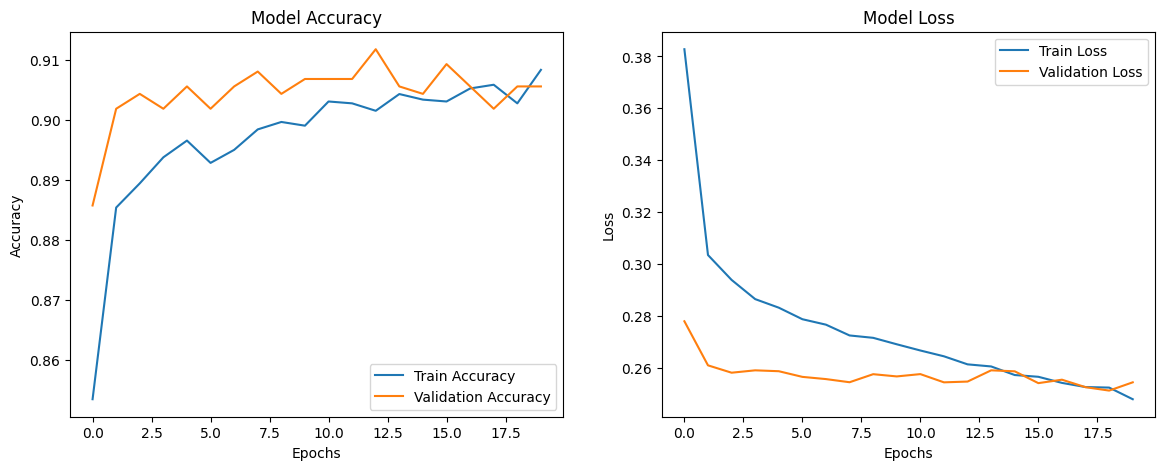

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [36]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy Score: 0.9055900621118013

Confusion Matrix:
 [[673  12]
 [ 64  56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95       685
           1       0.82      0.47      0.60       120

    accuracy                           0.91       805
   macro avg       0.87      0.72      0.77       805
weighted avg       0.90      0.91      0.89       805



[[673  12]   din 685 Alive: 673 corecte, doar 12 gresite
[ 64  56]]  din 120 Dead: 56 corecte, 64 gresite

In [37]:
#compute class weights (data is imbalanced)
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.5910760190965847), 1: np.float64(3.244959677419355)}


In [38]:
#retrain model with class weights
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [39]:
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    class_weight=class_weights_dict)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8434 - loss: 0.4187 - val_accuracy: 0.8460 - val_loss: 0.3638
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.8478 - loss: 0.3970 - val_accuracy: 0.8224 - val_loss: 0.3852
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8468 - loss: 0.3868 - val_accuracy: 0.8311 - val_loss: 0.3756
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - accuracy: 0.8493 - loss: 0.3845 - val_accuracy: 0.8708 - val_loss: 0.3343
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8496 - loss: 0.3811 - val_accuracy: 0.8273 - val_loss: 0.3825
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8472 - loss: 0.3802 - val_accuracy: 0.8410 - val_loss: 0.3690
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.8540 - loss: 0.3746 - val_accuracy: 0.8348 - val_loss: 0.3851
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.8552 - loss: 0.3736 - val_

In [40]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy Score: 0.8347826086956521

Confusion Matrix:
 [[588  97]
 [ 36  84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90       685
           1       0.46      0.70      0.56       120

    accuracy                           0.83       805
   macro avg       0.70      0.78      0.73       805
weighted avg       0.87      0.83      0.85       805



Dead detected: 84/120. For medical data this is the correct result, it is more important to detect sick patients even if you sometimes misclassify healthy ones.

In [ ]:
#optimized model
model_optimized = Sequential()
model_optimized.add(Input(shape=(15,)))

#first hidden layer 
model_optimized.add(Dense(256, activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(Dropout(0.3))

#second hidden layer
model_optimized.add(Dense(128, activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(Dropout(0.3))

#third
model_optimized.add(Dense(64, activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(Dropout(0.2))

#fourth
model_optimized.add(Dense(32, activation='relu'))
model_optimized.add(Dropout(0.2))

#output layer
model_optimized.add(Dense(1, activation='sigmoid'))


In [42]:
model_optimized.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,153 (192.00 KB)

 Trainable params: 48,257 (188.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [43]:
model_optimized.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

In [44]:
history_optimized = model_optimized.fit(X_train, y_train,
                                        epochs=20,
                                        batch_size=32,
                                        validation_data=(X_test, y_test),
                                        class_weight=class_weights_dict)


Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6952 - loss: 0.6667 - val_accuracy: 0.7540 - val_loss: 0.5981
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7369 - loss: 0.5571 - val_accuracy: 0.8124 - val_loss: 0.4804
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7596 - loss: 0.5337 - val_accuracy: 0.8273 - val_loss: 0.4183
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7661 - loss: 0.5058 - val_accuracy: 0.8298 - val_loss: 0.4062
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7633 - loss: 0.5132 - val_accuracy: 0.8099 - val_loss: 0.4249
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.4900 - val_accuracy: 0.8062 - val_loss: 0.4029
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7822 - loss: 0.4855 - val_accuracy: 0.8075 - val_loss: 0.4131
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7937 - loss: 0.4846 - val_accuracy: 0.

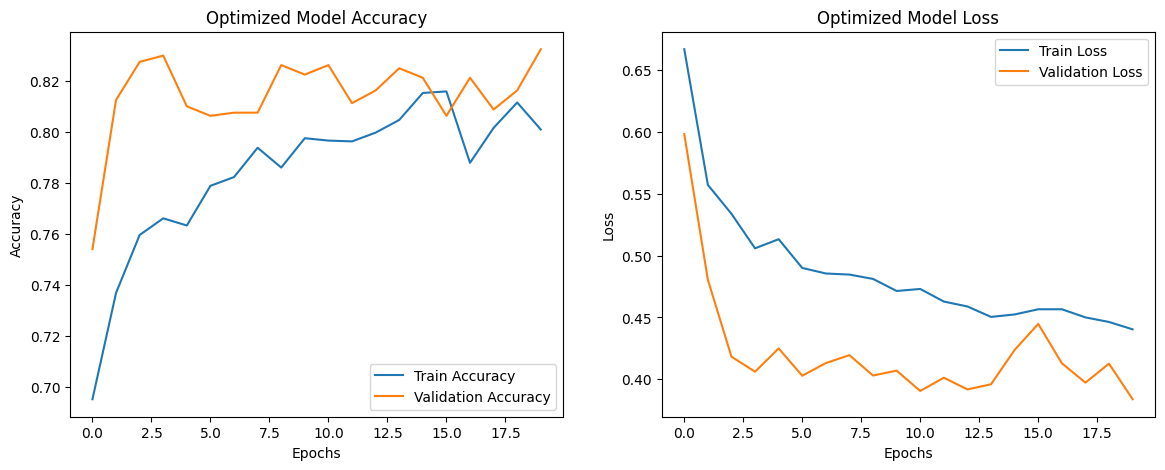

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_optimized.history['accuracy'], label='Train Accuracy')
ax1.plot(history_optimized.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Optimized Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_optimized.history['loss'], label='Train Loss')
ax2.plot(history_optimized.history['val_loss'], label='Validation Loss')
ax2.set_title('Optimized Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [46]:
y_pred_opt = (model_optimized.predict(X_test) > 0.5).astype(int)

print("Accuracy Score:", accuracy_score(y_test, y_pred_opt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy Score: 0.8322981366459627

Confusion Matrix:
 [[582 103]
 [ 32  88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       685
           1       0.46      0.73      0.57       120

    accuracy                           0.83       805
   macro avg       0.70      0.79      0.73       805
weighted avg       0.88      0.83      0.85       805



[[582  103]   Alive: 582 correct
[ 32   88]]  Dead: 88 out of 120 detected